* * *
<pre> INSEA                <i> Projet Statistiques Multivariées - 2025 </i></pre>
* * *


<pre align="left"> Mardi 4 Novembre  2025             <i> Author: Hicham Janati </i></pre>
* * *


Membre : MOURADI Houda

- Ce notebook contient 15 questions.
- Il faut executer tout le notebook (Run all cells) avant de l'envoyer: vérifier que les cellules sont exécutées dans le bon ordre et qu'il n'y a pas d'erreur, je ne vais pas débugger votre code. 
- Le code doit être propre et lisible et surtout comprendre ce qu'il fait par tous les membres du groupe.
- LIVRAISON UNIQUEMENT SUR DROPBOX (TOUT FICHIER ENVOYE PAR MAIL NE SERA PAS OUVERT):

https://www.dropbox.com/request/bs2Tafzm0Bzr7rroAGtc

Vous pouvez effectuer plusieurs uploads, seule la date la plus récente sera corrigée.

- Le but n'est pas de produire du code qui marche: le but est de comprendre et maîtriser les mécanismes derrière et savoir utiliser quoi et quand. Ce notebook est loin d'être self-contained, cherchez, lisez et apprenez à devenir auto-didacte.

<font color="orange"> 
I could not find a teammate so I apologize in advance for doing the project alone.

# Partie 1: Les données

Les données sont coupés en deux: train et test. Il s'agit d'une liste d'SMS avec leur labels (Y) spam / non spam.

In [1]:
import numpy as np

X_train = np.load("data/X_train.npy", allow_pickle=True)
X_test = np.load("data/X_test.npy", allow_pickle=True)
Y_train = np.load("data/Y_train.npy", allow_pickle=True)
Y_test = np.load("data/Y_test.npy", allow_pickle=True)


In [2]:
X_train[:4], Y_train[:4]

(array(['Play w computer? Aiyah i tok 2 u lor?',
        "Well there's not a lot of things happening in Lindsay on New years *sighs* Some bars in Ptbo and the blue heron has something going",
        'Dear are you angry i was busy dear',
        "Carlos'll be here in a minute if you still need to buy"],
       dtype=object),
 array([0, 0, 0, 0]))

On rappelle que les données de `test` doivent être utilisées pour évaluer le modèle final comme si elles étaient nouvelles en production -- non disponibles à l'entraînement -- toute opération d'apprentissage (y compris la validation croisée) doit être faite sur les données `train` uniquement.

### Libraries :

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import re
import time
from scipy.stats import ttest_ind
from sklearn.mixture import GaussianMixture
from scipy.optimize import linear_sum_assignment
from scipy.stats import chi2

### Question 1
En utilisant ```CountVectorizer``` de ```scikit-learn``` transformez les données. Quelle est l'utilité de cette opération ?

In [4]:
vectorizer = CountVectorizer()
V_X_train = vectorizer.fit_transform(X_train)

<font color="orange"> 

ML models can not process raw text directly, ``CountVectorizer`` transforms a text corpus into a numerical matrix by counting the occurrence of each word; therefore returning numerical features that can be used to train a model.


#### Question 2:
On modélise les données de chaque classe par une loi multinomiale. En utilisant ```MultinomialNB``` de scikit-learn, fittez un modèle et évaluez sa performance en calculant les scores de précision et de rappel.

In [5]:
clf = MultinomialNB()
clf.fit(V_X_train, Y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [6]:
V_X_test = vectorizer.transform(X_test)
Y_Pred = clf.predict(V_X_test)

print(f"Precision test: {precision_score(Y_test, Y_Pred):.4%}")
print(f"Recall test: {recall_score(Y_test, Y_Pred):.4%}")

Precision test: 96.5116%
Recall test: 89.0080%


<font color="orange"> 
The model shows excellent reliability in its positive predictions (96.51% precision) while maintaining a strong but not perfect ability to detect all positive cases (89.01% recall). Therefore, it rarely misclassifies hams as spam, though it allows a small number of spams to pass undetected.

### Question 3:
Implémentez votre propre modèle naive bayes multinomial en utilisant numpy. Comparez avec scikit-learn.

<font color="green"> 

## Multinomial Naive Bayes – Mathematical Summary :
We assume:

- Training data $ X \in \mathbb{N}^{n \times V} $, where:
  - $ n $ = number of samples (documents)
  - $ V $ = number of features (vocabulary size)
  - $ x_{i,j} $ = count of feature/word $ j $ in sample $ i $
- Labels $ y \in \{c_1, \dots, c_K\}^n $, where:
  - $ K $ = number of classes
  - $ \{c_1, \dots, c_K\} $ corresponds to `self.classes_`

The model uses a smoothing parameter $ \alpha = \texttt{self.alpha} > 0 $.

### Class Prior Probabilities :

For each class $c_k$ :

- Let $ N_k = \sum_{i=1}^{n} \mathbf{1}(y_i = c_k) $ be the number of training samples in class $c_k$.

- Total number of samples:
$N = \sum_{k=1}^{K} N_k = n$

- The **class prior** is:
$P(y = c_k) = \frac{N_k}{N}$

In the code, this is computed as:
- `class_counts[k] = N_k`
- `self.class_log_prior[k] = log P(y = c_k)`

So:
$\texttt{self.class\_log\_prior}[k] = \log \left( \frac{N_k}{N} \right)$

### Feature Probabilities per Class (Multinomial Model with Laplace Smoothing) :

For each class $c_k$, we take the sub-matrix of samples belonging to that class: $X^{(k)} = \{ x_i \mid y_i = c_k \}$

In code: `X_c = X[y == c]`.

- **Feature counts for class \(c_k\)** (sum over all samples in that class): $$\text{feature\_counts}_{k,j} = \sum_{i : y_i = c_k} x_{i,j}$$
This corresponds to: ``feature_counts = X_c.sum(axis=0)``

- **Total count of all features in class \(c_k\)** (sum over all samples in that class):
$$\text{total\_counts}_{k} = \sum_{j = 1}^{V} \text{feature\_counts}_{k,j}$$
This corresponds to: ``total_count = feature_counts.sum()``

Using Laplace smoothing with parameter $\alpha$, the conditional probability of feature $j$ given class $c_{k}$ is:
$$ P(x_j \mid y = c_k) = \theta_{k,j} = \frac{\text{feature\_counts}_{k,j} + \alpha}{\text{total\_counts}_{k} + \alpha V} $$

In code, we store the log of these probabilities (for numerical stability): ``self.feature_log_prob[k,j]`` = 
$$\log \theta_{k,j} = \log\left( \frac{\text{feature\_counts}_{k,j} + \alpha}{\text{total\_counts}_{k} + \alpha  V} \right) $$

### Joint Log-Likelihood for a New Sample :
Given a new sample represented by a feature-count vector $ x \in \mathbb{N}^{V} $  (vector of word counts).
Multinomial Naive Bayes assumption:
$$ P(x \mid y = c_k) \propto \prod_{j=1}^{V} \theta_{k,j}^{x_j} $$
Taking logs and adding the log prior :
$$\log P(y = c_k,x) = P(y = c_k) + \sum_{j=1}^{V} x_j \log \theta_{k,j} $$
This is exactly what _joint_log_likelihood computes in vectorized form:
$ J = $ ``joint_log_likelihood(self, X) = self._joint_log_likelihood(X)``
Where :
- $ J $ has shape $ (n_{test}, K) $.
- row $ i $, column $k$ : joint log-likelihood of sample $i$ for class $c_k$.

### Prediction :
- **Class prediction** \
The predicted class for sample $i$ is: $$ \hat{y}(x) = \arg\max_{k} J_{i,k} $$
In code:\
``predict(self, X) = self.classes_[np.argmax(joint_log_likelihood, axis=1)]``

- **Class probabilities** \
To get probabilities (not just argmax), we normalize:
1. Numerical Stability: Log-Max Trick :
For each sample $i$, subtract the maximum log value across all classes
$$L'_{i,k} = J_{i,k} - \max_{k'} \big( J_{i,k'} \big)$$
This step prevents numerical overflow when exponentiating.

2. Exponentiation and Normalization :
We convert back from log-space:
$$p_{i,k} = \frac{\exp\left( L'_{i,k} \right)}
                {\sum_{k'} \exp\left( L'_{i,k'} \right)}$$
So, each row of the probability matrix satisfies $\sum_{k=1}^K p_{i,k} = 1$

where:
- $p_{i,k}$ is the predicted probability that sample $i$ belongs to class $c_k$
- $K$ is the number of classes

This corresponds to the implementation:
```python
max_log = np.max(joint_log_likelihood, axis=1, keepdims=True)
log_probs = joint_log_likelihood - max_log
probs_unnorm = np.exp(log_probs)
probs = probs_unnorm / probs_unnorm.sum(axis=1, keepdims=True)

In [7]:
import numpy as np

class MultinomialNaiveBayes:
    def __init__(self, alpha=1.0):
        self.alpha = alpha
        self.classes_ = None  # Unique class labels in the training data
        self.class_log_prior = None # Log prior probability of each class
        self.feature_log_prob = None # Log probability of each feature given each class

    def fit(self, X, y):
        X = np.asarray(X) # array-like of shape (n_samples, n_features) Training data
        y = np.asarray(y) # array-like of shape (n_samples,) Target values (class labels)

        # Unique class labels
        self.classes_ = np.unique(y)

        # Estimate P(feature | class)
        self._update_feature_log_prob(X, y)

        # Estimate P(class)
        self._update_class_log_prior(y)

        return self

    def predict(self, X):
        X = np.asarray(X) #array-like of shape (n_samples, n_features) Test data
        joint_log_likelihood = self._joint_log_likelihood(X)
        return self.classes_[np.argmax(joint_log_likelihood, axis=1)]

    def predict_proba(self, X):
        # Probability estimates for each class.
        X = np.asarray(X)
        joint_log_likelihood = self._joint_log_likelihood(X) # array of shape (n_samples, n_classes)

        max_log = np.max(joint_log_likelihood, axis=1, keepdims=True)
        log_probs = joint_log_likelihood - max_log
        probs_unnorm = np.exp(log_probs)
        return probs_unnorm / probs_unnorm.sum(axis=1, keepdims=True)

    def _joint_log_likelihood(self, X):
        # Compute the unnormalized posterior log probability of X.
        # X @ feature_log_prob^T + log P(class)
        return X @ self.feature_log_prob.T + self.class_log_prior

    def _update_feature_log_prob(self, X, y):
        # Estimate feature log probability from data.
        n_classes = len(self.classes_)
        n_features = X.shape[1]

        # Initialize feature log probabilities matrix with shape (n_classes, n_features)
        self.feature_log_prob = np.zeros((n_classes, n_features), dtype=float)

        # Calculate feature log probabilities for each class
        for i, c in enumerate(self.classes_):
            # Subset of samples belonging to class c
            X_c = X[y == c]

            # Total count of each feature in class c
            feature_counts = X_c.sum(axis=0)       # shape (n_features,)
            total_count = feature_counts.sum()     # total number of words in the class

            # Laplace smoothing + conversion to log-space
            self.feature_log_prob[i] = np.log(
                (feature_counts + self.alpha) /
                (total_count + self.alpha * n_features)
            )

    def _update_class_log_prior(self, y):
        # Estimate class log prior probability from data.
        y = np.asarray(y)

        # Calculate class log prior probabilities
        class_counts = np.array([(y == c).sum() for c in self.classes_],
                                dtype=float)
        self.class_log_prior = np.log(class_counts / y.shape[0])


In [8]:
X_train_np = V_X_train.toarray()
X_test_np  = V_X_test.toarray()

y_train_np = np.array(Y_train)
y_test_np  = np.array(Y_test)

nb = MultinomialNaiveBayes(alpha=1)
nb.fit(X_train_np, y_train_np)

y_pred = nb.predict(X_test_np)

print(f"Precision test: {precision_score(y_test_np, y_pred):.4%}")
print(f"Recall test: {recall_score(y_test_np, y_pred):.4%}")

Precision test: 96.5116%
Recall test: 89.0080%


<font color="orange"> 
We obtained the same precision and recall scores as ``MultinomialNB`` of ``scikit-learn``.

### Question 4:
Afin de comparer avec d'autres modèles qui s'attendent à des inputs continus, on peut utiliser des fréquences de mots au lieu du nombre brut. Appliquez la transformation `TfIdf` de scikit-learn sur les données. Fittez des modèles différents: LDA, régression logistique, QDA et SVM. Essayez de battre la performance du MulinomialNB. 

In [9]:
tfidf = TfidfVectorizer()
X_train_tfidf  = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test) 

# convert the sparse matrix into a dense format
X_train_tfidf = X_train_tfidf.toarray()
X_test_tfidf = X_test_tfidf.toarray()

In [10]:
results = {}
# LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_tfidf, Y_train)
y_pred_lda = lda.predict(X_test_tfidf)
results["LDA"] = accuracy_score(Y_test, y_pred_lda)

# Régression logistique
logreg = LogisticRegression()
logreg.fit(X_train_tfidf, Y_train)
y_pred_logreg = logreg.predict(X_test_tfidf)
results["LogisticRegression"] = accuracy_score(Y_test, y_pred_logreg)

# QDA
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_tfidf , Y_train)
y_pred_qda = qda.predict(X_test_tfidf)
results["QDA"] = accuracy_score(Y_test, y_pred_qda)

# SVM 
svm = SVC(kernel='linear')
svm.fit(X_train_tfidf, Y_train)
y_pred_svm = svm.predict(X_test_tfidf)
results["SVM"] = accuracy_score(Y_test, y_pred_svm)


/Users/houda/Desktop/Projet SMV/.venv/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/houda/Desktop/Projet SMV/.venv/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [11]:
acc_NB = accuracy_score(Y_test, Y_Pred)
results["MultinomialNB"] = acc_NB

print("\n Accuracies :")
for model_name, acc in results.items():
    print(f"{model_name:20s} : {acc:.4%}")



 Accuracies :
LDA                  : 84.9605%
LogisticRegression   : 96.0158%
QDA                  : 50.3948%
SVM                  : 98.0617%
MultinomialNB        : 98.0976%


##### <font color="orange"> Since SVM accuracy is the closest to that of MultinomialNB, we can optimize SVM model by adjusting ``TfIdf`` parameters :

In [12]:
tfidf2 = TfidfVectorizer(
    ngram_range=(1,2), # unigrams and bigrams
)

In [13]:
X_train_tfidf2 = tfidf2.fit_transform(X_train)
X_test_tfidf2  = tfidf2.transform(X_test)

svm.fit(X_train_tfidf2, Y_train)
pred_svm = svm.predict(X_test_tfidf2)

print(f"Optimized SVM accuracy : {accuracy_score(Y_test, pred_svm):.4%}")
print(f"MultinomialNB accuracy : {acc_NB:.4%}")

Optimized SVM accuracy : 98.6719%
MultinomialNB accuracy : 98.0976%


### Question 5:
Visualisez la PCA et tSNE des données transformées.


### 5)a

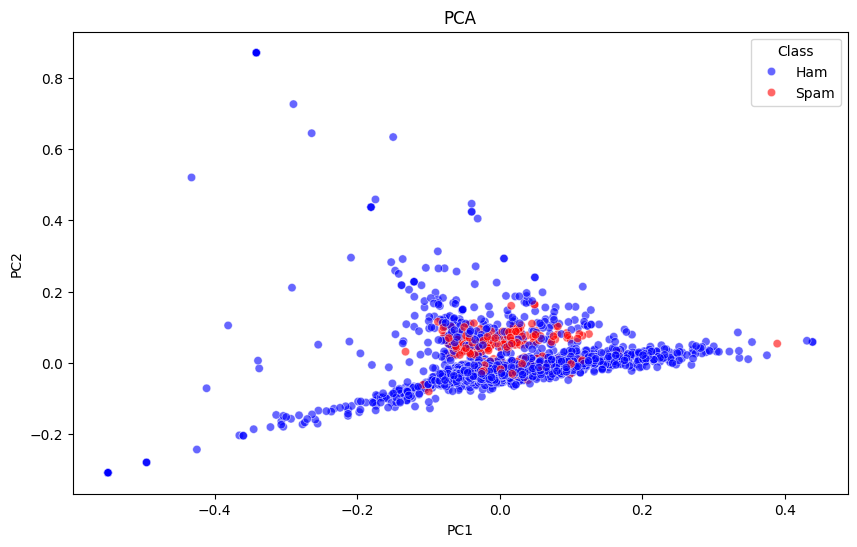

In [14]:
# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_tfidf)

df_plot = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Class": ["Spam" if y==1 else "Ham" for y in Y_train]
})

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_plot,
    x="PC1", y="PC2",
    hue="Class",
    palette={"Ham":"blue", "Spam":"red"},
    alpha=0.6
)
plt.title("PCA")
plt.show()


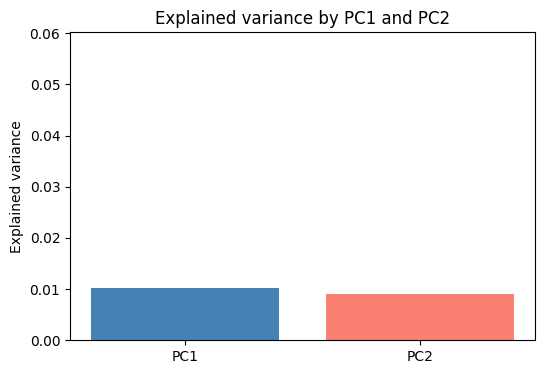

PC1: 0.0102 (1.02%)
PC2: 0.0091 (0.91%)


In [15]:
X = X_train_tfidf

# Standard PCA (all componants)
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X)   # adjust PCA

# get 2 first explained variances
var1 = pca.explained_variance_ratio_[0]
var2 = pca.explained_variance_ratio_[1]

plt.figure(figsize=(6,4))
plt.bar(["PC1", "PC2"], [var1, var2], color=['steelblue', 'salmon'])
plt.ylabel("Explained variance")
plt.title("Explained variance by PC1 and PC2")
plt.ylim(0, max(var1, var2) + 0.05)
plt.show()

print(f"PC1: {var1:.4f} ({var1:.2%})")
print(f"PC2: {var2:.4f} ({var2:.2%})")


<font color="orange"> 

### PCA Analysis :
##### Observations :
- The two classes are strongly mixed in most areas of the 2D plot.
- A slight tendency appears: spam messages (red) cluster a bit more toward the center, but the separation is still weak.
- Ham messages (blue) dominate the entire space because the dataset is imbalanced (many more ham than spam).
- Both classes tend to stay in the right–central region of the PCA plane. Some isolated ham points appear scattered elsewhere, but these don't form meaningful clusters.
- PCA visualization captures only around 2% of the total variance.

#### Conclusion :
The PCA visualization doesn't clearly separate ham and spam: both classes overlap heavily, although spam messages tend to cluster slightly toward the center-right region. This overlap indicates that PCA cannot capture the discriminative structure of the data in only two components, and that most of the informative variance lies in higher dimensions.

### 5)b

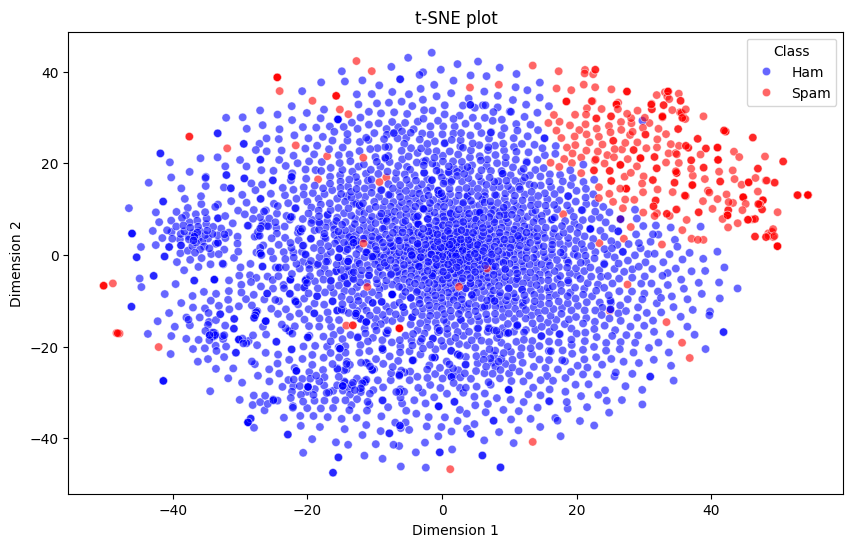

In [16]:
# t-SNE
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_train_tfidf)

df_tsne = pd.DataFrame({
    'Dim1': X_tsne[:,0],
    'Dim2': X_tsne[:,1],
    'Class': Y_train
})

df_tsne['Class'] = df_tsne['Class'].map({0:"Ham", 1:"Spam"})

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_tsne,
    x='Dim1', y='Dim2',
    hue='Class',
    palette={'Ham':'blue', 'Spam':'red'},
    alpha=0.6
)

plt.title("t-SNE plot")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

<font color="orange"> 

### PCA Analysis :
##### Observations :
- The t-SNE projection clearly reveals two distinct regions, with ham (blue) occupying a large, central and diffuse cluster, while spam (red) forms a much more compact and well-defined cluster on the upper left side.
- A few spam points still appear inside the ham region, indicating some overlap in the vocabulary used across classes, but the majority of spam messages cluster tightly together.
- The visualization suggests that spam messages share strong common patterns (repeated expressions).

#### Conclusion :
Overall, the t-SNE visualization provides a much clearer separation between ham and spam messages than PCA, revealing that spam texts form a dense and homogeneous cluster, while ham messages remain more broadly dispersed across the embedding space. This indicates that spam messages share strong lexical similarities and characteristic patterns that make them easier to identify, whereas ham messages are more diverse in content and vocabulary, which explains and supports the high performance achieved by our classifiers, especially SVM and MultinomialNB.

# Partie II: Introduction au NLP

Dans cette partie on utilise des transformations plus avancées basées sur la factorisation matricielle. L'un des premiers modèles à grand succès pour représenter les mots est `Word2Vec`. Étant donné un vocabulaire de taille V, on peut représenter un input par un vecteur binaire de taille V (one-hot encoding). Par exemple si le vocabulaire est
```["rouge", "chat", "souris", "courir", "mange", "ordinateur", "la", "le", ...]``` 
Alors on peut représenter chaque mot par son vecteur one-hot de taille V:
- "chat" -> [0, 1, 0, 0, 0, ...]
- "ordinateur" -> [0, 0, 0, 0, 0, 1, 0, ...]

La phrase "le chat mange la souris" peut être représentée par [0, 1, 1, 0, 1, 0, 1, 1, ...].

On construit un réseau de neurones simple capable de prédire le mot manquant au milieu d'une phrase avec des données comme:
- "le chat la souris" -> "mange"
- "la matrice est pas inversible" -> "n'" 
...
Ainsi, l'input du réseau doit être un vecteur de taille V. L'output doit être également **un vecteur de probabilités** de taille V. On prédit le mot avec la plus grande probabilité.

On considère un réseau de neurones à une couche cachée de dimension M (M neurones). Le réseau de neurones doit en sortie prédire un mot caché. Soit $x \in \mathbb R^V$ un one-hot vecteur. Le réseau de neurones peut être défini formellement comme suit. Soit $W_{in} \in \mathbb{R}^{V \times M}$ et $W_{out} \in \mathbb{R}^{M \times V}$. 

$$ g(x) = W_{out}(W_{in}x) \in \mathbb R^{V} $$

Pour obtenir un vecteur output positif et sommant à 1 (des probabilités sur les mots), on applique la fonction softmax:
$$ softmax: z \in \mathbb R^V \mapsto \left[\frac{e^{z_1}}{\sum_j e^{z_j}}, \dots, \frac{e^{z_V}}{\sum_j e^{z_j}}  \right]^\top$$

Ainsi on définit: $ neuralnet(x) = softmax(g(x))$ et on entraîne le modèle avec la loss cross-entropy.
 
Après avoir entraîné le modèle, les ligne de la matrice $W_{in}$ sont les embeddings des mots du vocabulaire.


On commence par télécharger le modèle word2vec (peut prendre du temps):

In [17]:
import gensim.downloader as api

word2vec = api.load("word2vec-google-news-300")

word2vec est n'est qu'un dictionnaire spécial "mot" -> vecteur:


In [18]:
word2vec["computer"]

array([ 1.07421875e-01, -2.01171875e-01,  1.23046875e-01,  2.11914062e-01,
       -9.13085938e-02,  2.16796875e-01, -1.31835938e-01,  8.30078125e-02,
        2.02148438e-01,  4.78515625e-02,  3.66210938e-02, -2.45361328e-02,
        2.39257812e-02, -1.60156250e-01, -2.61230469e-02,  9.71679688e-02,
       -6.34765625e-02,  1.84570312e-01,  1.70898438e-01, -1.63085938e-01,
       -1.09375000e-01,  1.49414062e-01, -4.65393066e-04,  9.61914062e-02,
        1.68945312e-01,  2.60925293e-03,  8.93554688e-02,  6.49414062e-02,
        3.56445312e-02, -6.93359375e-02, -1.46484375e-01, -1.21093750e-01,
       -2.27539062e-01,  2.45361328e-02, -1.24511719e-01, -3.18359375e-01,
       -2.20703125e-01,  1.30859375e-01,  3.66210938e-02, -3.63769531e-02,
       -1.13281250e-01,  1.95312500e-01,  9.76562500e-02,  1.26953125e-01,
        6.59179688e-02,  6.93359375e-02,  1.02539062e-02,  1.75781250e-01,
       -1.68945312e-01,  1.21307373e-03, -2.98828125e-01, -1.15234375e-01,
        5.66406250e-02, -

On peut obtenir l'embedding de plusieurs mots directement dans une liste. L'embedding d'une phrase est souvent défini comme la moyenne des embeddings de ses mots.

In [19]:
word2vec[["computer", "mouse", "keyboard"]].shape

(3, 300)

In [20]:
word2vec[["I", "love", "computers"]].mean(axis=0).shape

(300,)

### Question 6
Pour appliquer word2vec aux SMS, il faut d'abord les découper en mots. Implémentez une fonction naïve qui transforme un SMS en liste de mots ou _tokens_. C'est ce qu'on appelle un tokenizer.

In [21]:
def tokenizer(sms):
    sms = sms.lower()
    sms = re.sub(r'[^a-z0-9\s]', ' ', sms)  # removes poctuation
    return sms.split()

In [22]:
X_train[0]

'Play w computer? Aiyah i tok 2 u lor?'

In [23]:
tokenizer(X_train[0])

['play', 'w', 'computer', 'aiyah', 'i', 'tok', '2', 'u', 'lor']

### Question 7
On peut vérifier si un mot fait partie du vocabulaire avec le test:

In [24]:
"computer" in word2vec

True

Proposez une solution pour appliquer word2vec aux données SMS. Est-il meilleur comme embedding comparé au `CountVectorizer` ?

In [25]:
tokenized_X = [tokenizer(sms) for sms in X_train]
import numpy as np

def sms_to_w2v(sms, model=word2vec):
    tokens = tokenizer(sms)
    
    # Only keep the word in the model
    tokens = [t for t in tokens if t in model]
    
    if not tokens:
        return np.zeros(model.vector_size, dtype=np.float32)
    
    # SMS embeddings
    return model[tokens].mean(axis=0)

X_train_w2v = np.vstack([sms_to_w2v(sms) for sms in X_train])
X_test_w2v  = np.vstack([sms_to_w2v(sms) for sms in X_test])

print(X_train_w2v)
print(X_test_w2v)


[[-0.08570099 -0.04025269  0.04141617 ... -0.14164734 -0.08255005
   0.08383942]
 [ 0.0268527   0.0609769  -0.00195763 ... -0.00982389  0.05346402
  -0.04467773]
 [ 0.05659485  0.08734894  0.10229492 ... -0.00540161 -0.0302124
   0.12578583]
 ...
 [-0.00987413  0.01295     0.01630317 ... -0.07673984  0.01999834
   0.02570936]
 [-0.06494331  0.07674313  0.07283401 ... -0.08713913  0.01727009
   0.03263116]
 [ 0.0289917   0.03221385  0.02372869 ... -0.04340617 -0.01364962
  -0.02793089]]
[[ 0.03932104  0.02011742  0.03684451 ... -0.0751861   0.04855404
   0.0418825 ]
 [-0.01723539  0.02344689  0.07056603 ... -0.07206844 -0.04443359
  -0.06736403]
 [ 0.11004883  0.00592285  0.09062805 ... -0.07962097  0.00368652
  -0.02425446]
 ...
 [-0.02903158  0.06398704  0.04885587 ... -0.0688428  -0.01910054
   0.02340976]
 [ 0.06967689  0.01813007  0.00082924 ... -0.09319226  0.03849424
  -0.02388263]
 [ 0.04330226  0.02789402  0.0523856  ... -0.03089687  0.02588763
  -0.02763149]]


<font color="orange"> 

##### To compare Word2Vec with CountVectorizer, we trained the same classifier (Logistic Regression) on both representations: produced by CountVectorizer (V_X_train), and by averaging Word2Vec word vectors (X_train_w2v) :

In [26]:
logreg.fit(X_train_w2v, Y_train)

y_pred = logreg.predict(X_test_w2v)
print(f"Accuracy (word2vec): {accuracy_score(Y_test, y_pred):.3%}")

Accuracy (word2vec): 95.980%


In [27]:
logreg.fit(V_X_train, Y_train)

y_pred = logreg.predict(V_X_test)
print(f"Accuracy (CountVectorizer): {accuracy_score(Y_test, y_pred):.3%}")

Accuracy (CountVectorizer): 97.523%


<font color="orange"> 

#### Conclusion : 
Using Word2Vec embeddings on SMS messages yields a good performance (≈96%), but it remains slightly lower than CountVectorizer-based features (≈97.5%). This indicates that, simple texts like SMS, classic Bag-of-Words representations still capture discriminative information more effectively than dense Word2Vec embeddings, which tends to smooth the text and lose some keyword-level signals important for spam detection.

`Word2vec` (2013) est l'un des premiers modèles de représentation vectorielle du langage naturel. L'une de ses limitations principales est le fait de ne pas pouvoir représenter des mots (ou bouts de mots) non-vus lors de l'entraînement. Quelques années plus tard, plusieurs avancées ont été introduites pour y remédier:

### 1) Améliorer la tokenization:
1. Au lieu de considérer un vocabulaire avec des mots, on considère un vocabulaire avec les mots, et les bouts de mots (ngrams):

    "diagonalisation matricielle" -> "diagonal", "isation", " ", "matric", "ielle". 

    Ceci est utilisé dans le modèle `fastText` (2016) dont l'architecture est similaire à celle de Word2Vec.

2. WordPiece: approche bottom-up où le vocabulaire des tokens est construit en mergeant les caractères (a-Z, 0-9, symboles et ponctuation) + Ajouter des tokens spéciaux "[UNK]" (unknow) pour gérer les tokens non-vus, "[SEP]" (séparateur entre phrases ou textes), "[MASK]" (token qui veut dire "ce mot est à prédire") etc. Ce tokenizer est utilisé dans l'un des premiers modèles basés sur l'architecture Transformer (BERT) (2018).

3. Byte-pair encoding (BPE): similaire à WordPiece mais à l'échelle du byte.  Ceci permet d'encoder n'importe quel string dans n'importe quelle langue: mots rares, typos, emojis, kanji... C'est le tokenizer adopté par l'un des fameux modèles de traduction à l'époque (Neural Machine Translation -- NMT 2015) pour traduire les mots rares; et ensuite par les modèles GPT (2018). Avec BPE, on n'a plus besoin du token spécial _unknown_ [UNK]. Vous pouvez voir comment le texte est tokenisé par GPT en visitant https://platform.openai.com/tokenizer. 

### 2) Améliorer l'architecture

1. Limites de Word2Vec et companie:

La nature des données de langage est séquentielle (comme les séries temporelles, mot après mot..), or les modèles comme Word2Vec et ses variantes (Fasttext, GloVe) ne prennent pas en considération l'ordre des mots: ils sont appliqués à des _bag of words_. En plus, même si ses modèles utilisent le contexte voisin, après l'entraînement, l'embedding d'un mot est le même quelque soit son contexte ce qui limite la compréhension des différentes nuances d'un même mot. 

2. Recurrent Neural Networks:

L'architecture des réseaux de neurones récurrents (RNN) et ses variantes (LSTM, GRU) développés principalement dans les années 1990 sont revisités en (2013-2020) après le succès du deep learning (2012+) avec la réalisation de la grande puissance de calcul des GPUs. Ils permettent de prendre en considération l'aspect temporel des données mais restent difficiles à entraîner (nécessitent beaucoup de temps + instabilité des gradients). 

3. Transformers (en très bref):

En 2017, l'architecture des Transformers est introduite. Son avantage principal est son formalisme matriciel qui est beaucoup plus parallélisable que les RNNs, et donc permet d'entraîner des modèles plus grands sur des données beaucoup plus grandes. Prenons le cas d'une architecture générative (GPT). Un transformer définit une structure appelée _Self-Attention Head_ qui fonctionne comme suit.
Étant donnés les embeddings (statiques comme ceux de Word2Vec) des tokens d'une phrase, le mécanisme d'attention consiste à calculer des scores de similarités (produits scalaires) entre chaque paire d'embeddings, ceci permet d'obtenir une matrice de scores "d'attention" entre les tokens.

Par exemple, pour une phrase "Il me faut un tapis pour la souris Logitec", l'embedding du mot "souris" sera pondéré par ses scores de similarité avec chacun des autres mots ["Il", "me", "faut", "un", "tapis", "pour", "la", "logitec"]. Ainsi, l'embedding d'un même mot dépend du contexte. Ceci permettra de distinguer la souris (animal) de la souris d'ordinateur.

 Ceci reste une explication très simpliste du mécanisme d'attention, pour visualiser le concept, regardez la vidéo de 3b1b https://www.youtube.com/watch?v=eMlx5fFNoYc.







## III Partie 3 - Embeddings basés sur les transformers

Dans cette partie, on passe à l'artillerie lourde: embeddings basés sur les transformers. On utilise ceux de BERT plutôt que GPT car BERT a été conçu pour la classification supervisée alors que GPT pour la génération de texte: l'embedding de BERT est plus pertinent pour notre problématique.

On commence par tokeniser les données. Voici ce que donne le tokenizer avec une phrase par exemple:

In [28]:
from transformers import AutoTokenizer, AutoModel
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")


In [29]:
text = "Hey, are you free tomorrow at 8 ? gotta catch up bud."
tokens = tokenizer.tokenize(text)
tokens


['hey',
 ',',
 'are',
 'you',
 'free',
 'tomorrow',
 'at',
 '8',
 '?',
 'gotta',
 'catch',
 'up',
 'bud',
 '.']

Le modèle BERT en revanche ne s'attend pas à des tokens en texte, mais aux token_ids:

In [30]:
text = "Hey, are you free tomorrow at 8 ? gotta catch up bud"
token_ids = tokenizer(text, return_tensors="pt")
token_ids


{'input_ids': tensor([[  101,  4931,  1010,  2024,  2017,  2489,  4826,  2012,  1022,  1029,
         10657,  4608,  2039, 13007,   102]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

On fait appel ensuite au modèle BERT. On peut voir les composants de son architecture:

In [31]:
bert_model = AutoModel.from_pretrained("bert-base-uncased")
bert_model.eval()
bert_model


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False

On applique le modèle aux token_ids sans calcul de gradient:

In [32]:
import torch
with torch.no_grad():
    outputs = bert_model(**token_ids)
outputs

BaseModelOutputWithPoolingAndCrossAttentions(last_hidden_state=tensor([[[ 0.3836,  0.0548, -0.0066,  ..., -0.2580,  0.3390,  0.2724],
         [ 0.6628, -0.0560,  0.9965,  ...,  0.0643,  1.2164, -0.4075],
         [ 0.1342,  0.0883,  0.7119,  ..., -0.0816,  1.2578,  0.1409],
         ...,
         [ 0.8804, -0.9000,  0.7776,  ...,  0.3333,  0.4174, -0.7230],
         [ 0.4084, -0.3247,  0.8299,  ...,  0.8601,  0.5027, -0.3476],
         [ 0.4914,  0.0527, -0.1084,  ..., -0.1167, -0.4205, -0.2667]]]), pooler_output=tensor([[-8.6382e-01, -5.2100e-01, -9.1143e-01,  7.4742e-01,  6.9650e-01,
         -2.0079e-01,  8.5602e-01,  3.7551e-01, -7.7920e-01, -9.9999e-01,
         -4.6733e-01,  8.6761e-01,  9.8091e-01,  5.1904e-01,  9.3339e-01,
         -7.2372e-01, -2.1201e-01, -6.3463e-01,  3.1704e-01, -3.3231e-01,
          7.0444e-01,  9.9999e-01,  5.4937e-02,  3.5607e-01,  5.5947e-01,
          9.8429e-01, -7.8516e-01,  9.2724e-01,  9.5860e-01,  7.1539e-01,
         -6.2374e-01,  1.7224e-01, -

On peut accéder aux embeddings en cherchant la dernière couche cachée:

In [33]:
outputs.last_hidden_state

tensor([[[ 0.3836,  0.0548, -0.0066,  ..., -0.2580,  0.3390,  0.2724],
         [ 0.6628, -0.0560,  0.9965,  ...,  0.0643,  1.2164, -0.4075],
         [ 0.1342,  0.0883,  0.7119,  ..., -0.0816,  1.2578,  0.1409],
         ...,
         [ 0.8804, -0.9000,  0.7776,  ...,  0.3333,  0.4174, -0.7230],
         [ 0.4084, -0.3247,  0.8299,  ...,  0.8601,  0.5027, -0.3476],
         [ 0.4914,  0.0527, -0.1084,  ..., -0.1167, -0.4205, -0.2667]]])

### Question 8
Expliquez la dimension obtenue de ces embeddings. On souhaite obtenir les embeddings de toutes les données directement. Appliquez la tokenization à la liste de textes suivante. Quel problème se pose ? Comment y remédier ?

In [34]:
outputs.last_hidden_state.shape

torch.Size([1, 15, 768])

<font color="orange"> 
The tocken_ids contains 15 tokens, BERT outputs a tensor of size (1, 15, 768), meaning: one message, fifteen tokens, and for each token a 768-dimensional embedding. This three-dimensional output is simply the collection of all token embeddings produced by the model. In other words, for the IDs fed into the BERT model, which produces, for every token, a dense vector of 768 numbers that captures its meaning and context inside the sentence.

<font color="orange"> 

#### The problem is that the sentences have different lengths (first has 16 tockens, second has 10).

In [35]:
texts = ["Hey, are you free tomorrow at 8 ? gotta catch up bud.", "Sure thing, let's go."]
token_ids = tokenizer(
    texts,
    padding=True,        # adds padding so that all sequences have the same length
    return_tensors="pt"
)


### Question 9
Après avoir fixé le problème, analysez les tokens obtenus et le `attention_mask` de l'output. Comment peut-on savoir où le `padding` a été appliqué ?

In [36]:
token_ids

{'input_ids': tensor([[  101,  4931,  1010,  2024,  2017,  2489,  4826,  2012,  1022,  1029,
         10657,  4608,  2039, 13007,  1012,   102],
        [  101,  2469,  2518,  1010,  2292,  1005,  1055,  2175,  1012,   102,
             0,     0,     0,     0,     0,     0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0]])}

<font color="orange"> 
After fixing the padding issue, the token_ids object now contains sequences of equal length for both sentences.

In the `input_ids`, we clearly see that the first sentence is fully filled with non-zero token IDs, while the second sentence contains several 0 values at the end. These zeros correspond to the padding token, which is automatically added to shorter sentences so that all sequences have the same length. 

The `attention_mask` confirms this: a value of 1 marks a real token, and a value of 0 marks padding. In the first sentence, the mask is [1, 1, ..., 1] because no padding was needed. In the second sentence, the mask ends with several zeros, exactly at the positions where `input_ids` contains zeros. 
Therefore, we can identify where padding was applied simply by looking at:
- the positions where `input_ids` contains 0,
- the positions where the attention_mask contains 0.

### Question 10
L'embedding d'une phrase est la moyenne des embeddings de ses tokens. Appliquez BERT à une liste des donnés spams (X_train[:10]). Calculez le temps pris par cette opération en utilisant la librairie `time`. 

In [37]:
texts = X_train[:10].astype(str).tolist()

start = time.time()

# Tokenization with padding
encodings = tokenizer(
    texts,
    padding=True,
    return_tensors="pt"
)

with torch.no_grad():
    outputs = bert_model(**encodings)

hidden_states = outputs.last_hidden_state  

# Mean of token embeddings
sentence_embeddings = hidden_states.mean(dim=1) 

end = time.time()
print("Time taken:", end - start, "seconds")
sentence_embeddings.shape

Time taken: 0.16239070892333984 seconds


torch.Size([10, 768])

<font color="orange"> 
The BERT encoding of the first 10 SMS messages took only 0.18 seconds, demonstrating the model’s fast inference capability. Each message was mapped into a 768-dimensional vector space, providing rich contextual representations.

### Question 11
Avec une GPU, ce calcul peut être jusqu'à 100x fois plus rapide. On vous fournit les embeddings des données `X_train` et `X_test` calculés avec BERT. Refaire l'étape de visualisation et classification avec ces embeddings pour comparer. 

### 11)a Vizualisation

In [38]:
import numpy as np
X_train_bert = np.load("data/embeddings_train.npy")
X_test_bert = np.load("data/embeddings_test.npy")


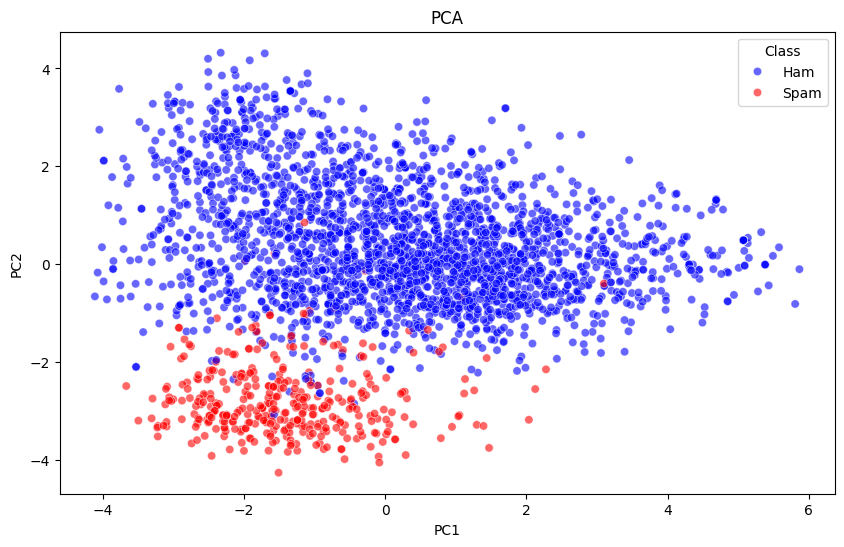

In [39]:
# PCA
X_pca = pca.fit_transform(X_train_bert)

df_plot = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "Class": ["Spam" if y==1 else "Ham" for y in Y_train]
})

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_plot,
    x="PC1", y="PC2",
    hue="Class",
    palette={"Ham":"blue", "Spam":"red"},
    alpha=0.6
)
plt.title("PCA")
plt.show()

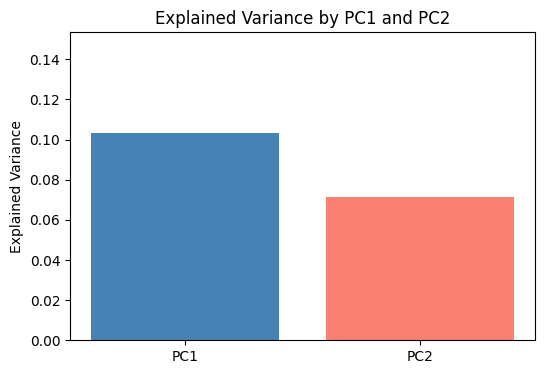

PC1: 0.1035 (10.35%)
PC2: 0.0716 (7.16%)


In [40]:
X_pca_full = pca_full.fit_transform(X_train_bert) 

var1 = pca.explained_variance_ratio_[0]
var2 = pca.explained_variance_ratio_[1]

plt.figure(figsize=(6,4))
plt.bar(["PC1", "PC2"], [var1, var2], color=['steelblue', 'salmon'])
plt.ylabel("Explained Variance")
plt.title("Explained Variance by PC1 and PC2")
plt.ylim(0, max(var1, var2) + 0.05) 
plt.show()

print(f"PC1: {var1:.4f} ({var1:.2%})")
print(f"PC2: {var2:.4f} ({var2:.2%})")

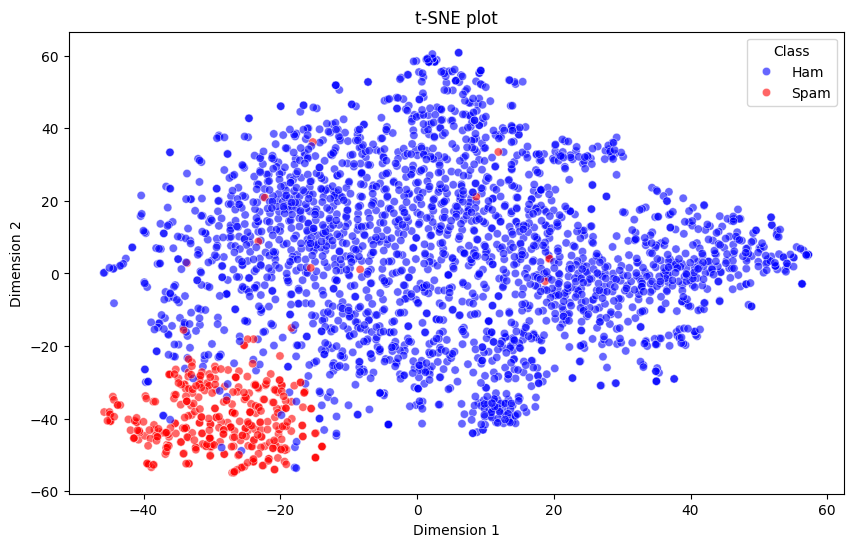

In [41]:
# t-SNE
X_tsne = tsne.fit_transform(X_train_bert)

df_tsne = pd.DataFrame({
    'Dim1': X_tsne[:,0],
    'Dim2': X_tsne[:,1],
    'Class': Y_train
})

df_tsne['Class'] = df_tsne['Class'].map({0:"Ham", 1:"Spam"})

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_tsne,
    x='Dim1', y='Dim2',
    hue='Class',
    palette={'Ham':'blue', 'Spam':'red'},
    alpha=0.6
)

plt.title("t-SNE plot")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

<font color="orange"> 

#### Observations :
- The PCA projection of the BERT embeddings shows a clear separation between ham and spam messages. Spam points (in red) cluster together in the lower part of the plot, while ham messages (in blue) occupy a broader region in the upper part, with a few overlaps and some spams scattered around.
- The first two principal components together capture around 17.5% of the information contained in the BERT embeddings.
- The t-SNE plot gives a much clearer separation between the two classes than PCA in around the same region, with a few overlaps.

#### Conclusion :
The visualizations confirm that BERT embeddings are highly informative for spam detection in comparison with CountVectoriser-based one. Although PCA captures only a small portion of the variance (17.5%), it is still much higher than the one we have found before (2%). The t-SNE visualization provides an even clearer separation, with spam forming a tight and distinct cluster, demonstrating that BERT effectively embeds semantic differences between the two categories. 
Overall, these results suggest that classification models trained on BERT embeddings can achieve excellent performance, as the classes are already well separated in the embedding space.

### 11)b Classification :

In [42]:
results_emb = {}
# LDA
lda.fit(X_train_bert, Y_train)
y_pred_lda = lda.predict(X_test_bert)
results_emb["LDA_emb"] = accuracy_score(Y_test, y_pred_lda)

# Régression logistique
logreg.fit(X_train_bert, Y_train)
y_pred_logreg = logreg.predict(X_test_bert)
results_emb["LogisticRegression_emb"] = accuracy_score(Y_test, y_pred_logreg)

# QDA
qda.fit(X_train_bert, Y_train)
y_pred_qda = qda.predict(X_test_bert)
results_emb["QDA_emb"] = accuracy_score(Y_test, y_pred_qda)

# SVM 
svm.fit(X_train_bert, Y_train)
y_pred_svm = svm.predict(X_test_bert)
results_emb["SVM_emb"] = accuracy_score(Y_test, y_pred_svm)

/Users/houda/Desktop/Projet SMV/.venv/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/houda/Desktop/Projet SMV/.venv/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [43]:
print("\n Accuracies :")
for model_name, acc in results_emb.items():
    print(f"{model_name:20s} : {acc:.4%}")


 Accuracies :
LDA_emb              : 99.1385%
LogisticRegression_emb : 99.3180%
QDA_emb              : 86.6116%
SVM_emb              : 98.9950%


In [44]:
print("\n Embedding accuracies :")
for model_name, acc in results.items():
    print(f"{model_name:20s} : {acc:.4%}")


 Embedding accuracies :
LDA                  : 84.9605%
LogisticRegression   : 96.0158%
QDA                  : 50.3948%
SVM                  : 98.0617%
MultinomialNB        : 98.0976%


<font color="orange"> 
All models used have increased performance when trained on BERT embeddings, outperforming both CountVectorizer and Word2Vec.

# IV Partie 4: Data drift 
En production, les données nouvelles peuvent devenir de plus en plus différentes des données d'entraînement avec le temps: on parle de _data drift_ ou de _distribution shift_. Il faut alors réentraîner le modèle sur des données plus récentes. 


### Question 12
Appliquez une PCA pour la réduire et implémentez un test statistique pour comparer les moyennes des embeddings Train et Test.

In [45]:
# Reduction
X_train_pca = pca.fit_transform(X_train_bert)
X_test_pca  = pca.transform(X_test_bert)

# Independent two-sample t-test on PC1 and PC2
tstat_pc1, pval_pc1 = ttest_ind(X_train_pca[:,0], X_test_pca[:,0])
tstat_pc2, pval_pc2 = ttest_ind(X_train_pca[:,1], X_test_pca[:,1])

alpha = 0.05

if pval_pc1 < alpha or pval_pc2 < alpha:
    print("Potential data drift detected.")
else:
    print("No significant data drift detected.")


No significant data drift detected.


### Question 13
En pratique, comparer les moyennes des distributions n'est pas suffisant pour détecter le drift. Si on obtient les vrais labels (même avec un petit retard), alors  on peut calculer les métriques de performances (précision, rappel) au cours du temps. Sinon, on peut chercher à prédire si un échantillon vient du train ou du test ! L'idée est: si un modèle ML est capable de les distinguer: il y a forcément un drift. Trouvez le meilleur modèle capable de le faire en utilisant les embeddings de BERT. 

In [46]:
# Build dataset for drift detection
X = np.vstack([X_train_bert, X_test_bert])
y = np.array([0]*len(X_train_bert) + [1]*len(X_test_bert))  # 0=train, 1=test

# Split into detection-train/detection-test
X_train_drift, X_test_drift, y_train_drift, y_test_drift = train_test_split(
    X, y, test_size=0.3, random_state=42, shuffle=True
)

In [47]:
results_d = {}

# Helper function to compute metrics
def compute_metrics(name, y_true, y_pred):
    results_d[name] = {
        "accuracy" : accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall"   : recall_score(y_true, y_pred)
    }

In [48]:
# Logistic Regression
logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train_drift, y_train_drift)
pred_lr = logreg.predict(X_test_drift)
compute_metrics("Logistic Regression", y_test_drift, pred_lr)

# SVM
svm.fit(X_train_drift, y_train_drift)
pred_svm = svm.predict(X_test_drift)
compute_metrics("Linear SVM", y_test_drift, pred_svm)

# QDA
qda.fit(X_train_drift, y_train_drift)
pred_lr = qda.predict(X_test_drift)
compute_metrics("QDA", y_test_drift, pred_lr)

# LDA
lda.fit(X_train_drift, y_train_drift)
pred_lr = lda.predict(X_test_drift)
compute_metrics("LDA", y_test_drift, pred_lr)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_drift, y_train_drift)
pred_rf = rf.predict(X_test_drift)
compute_metrics("Random Forest", y_test_drift, pred_rf)

/Users/houda/Desktop/Projet SMV/.venv/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/Users/houda/Desktop/Projet SMV/.venv/lib/python3.11/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


In [49]:
# Display results
for model, metrics in results_d.items():
    print(f"\n {model}")
    print(f"  Accuracy : {metrics['accuracy']:.4%}")
    print(f"  Precision: {metrics['precision']:.4%}")
    print(f"  Recall   : {metrics['recall']:.4%}")


 Logistic Regression
  Accuracy : 49.3421%
  Precision: 47.6190%
  Recall   : 52.1739%

 Linear SVM
  Accuracy : 49.1029%
  Precision: 47.4273%
  Recall   : 52.6708%

 QDA
  Accuracy : 49.0431%
  Precision: 47.6847%
  Recall   : 60.1242%

 LDA
  Accuracy : 49.4617%
  Precision: 47.6798%
  Recall   : 51.0559%

 Random Forest
  Accuracy : 48.8636%
  Precision: 47.1847%
  Recall   : 52.0497%


<font color="orange"> 
Scores around 50%, meaning the classifier is performing at chance level (50 50 chance), which happens when Train and Test embeddings are indistinguishable — therefore, no data drift is present.

## V Partie 5: Modélisation non supervisée

#### Question 14
Sans utiliser les labels, modéliser en utilisant le modèle GMM de `scikit-learn` les données (BERT embeddings + PCA) en utilisant quelques modèles différents (nombre de composantes 2 vs 3 -- et type de covariance). Comparez les performances avec les vrais labels.

In [50]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_bert)
X_test_pca  = pca.transform(X_test_bert)
X_pca = np.vstack([X_train_pca, X_test_pca])
Y_true_full = np.concatenate([Y_train, Y_test])

In [51]:
models = {}
components = [2, 3]
cov_types = ["full", "tied", "diag", "spherical"]

for k in components:
    for cov in ["full", "tied", "diag", "spherical"]:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42)
        gmm.fit(X_pca)  # PCA-reduced BERT embeddings
        labels = gmm.predict(X_pca)
        models[f"{k}_{cov}"] = labels

rows = []

for k in components:
    for cov in cov_types:
        preds = models[f"{k}_{cov}"]

        acc = accuracy_score(Y_true_full, preds)
        ari = adjusted_rand_score(Y_true_full, preds)
        nmi = normalized_mutual_info_score(Y_true_full, preds)

        rows.append([k, cov, acc, ari, nmi])

df_results = pd.DataFrame(rows, columns=["Components", "Covariance", "Accuracy", "ARI", "NMI"])
df_results


,Components,Covariance,Accuracy,ARI,NMI
0,2,full,0.633345,0.070944,0.159082
1,2,tied,0.503410,-0.030068,0.085691
2,2,diag,0.627961,0.065412,0.156129
3,2,spherical,0.430905,-0.072139,0.086084
4,3,full,0.692749,0.305941,0.430113
5,3,tied,0.646985,0.275345,0.382963
6,3,diag,0.736899,0.344863,0.447831
7,3,spherical,0.587940,0.273653,0.400186


<font color="orange"> 
Increasing the number of Gaussian components from 2 to 3 significantly improves clustering performance, indicating that the BERT space contains at least three meaningful latent groups rather than a strict binary ham/spam split.

<font color="orange"> 

#### With only 2 clusters, GMM forces spam and ham embeddings into a binary separation. Yellow ≈ ham, Purple ≈ spam (not exact labels but clusters).

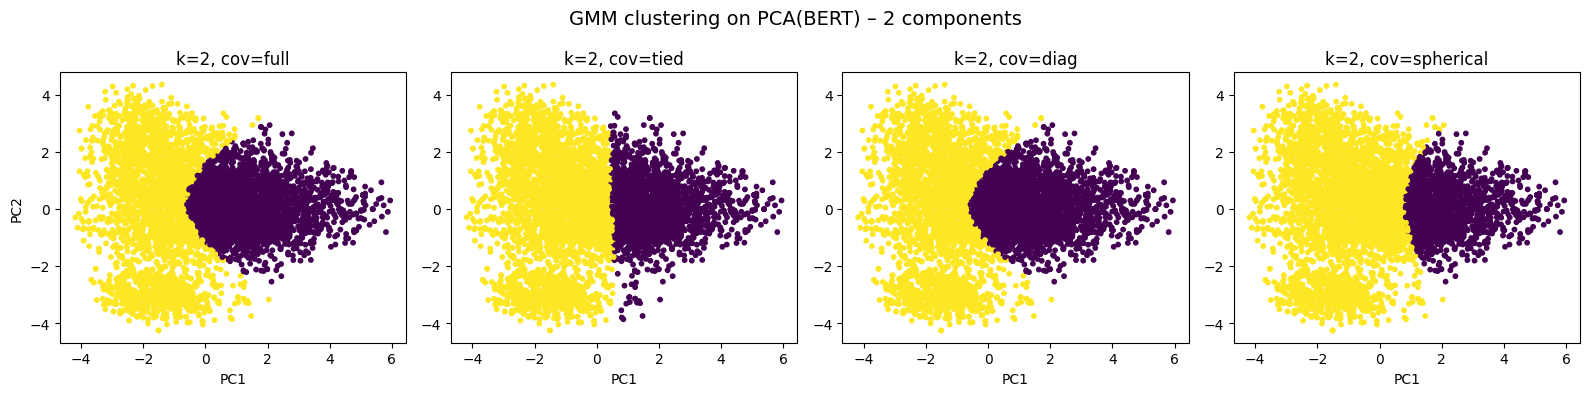

In [52]:
plt.figure(figsize=(16, 4))

for i, cov in enumerate(cov_types):
    gmm = GaussianMixture(n_components=2, covariance_type=cov, random_state=42)
    gmm.fit(X_pca)
    labels = gmm.predict(X_pca)

    ax = plt.subplot(1, 4, i + 1)
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=10, cmap="viridis")
    ax.set_title(f"k=2, cov={cov}")
    ax.set_xlabel("PC1")
    if i == 0:
        ax.set_ylabel("PC2")

plt.suptitle("GMM clustering on PCA(BERT) – 2 components", fontsize=14)
plt.tight_layout()
plt.show()

<font color="orange"> 

#### k = 2, covariance = full
- Clusters are clearly separated along PC1.
- Full covariance allows each cluster to model correlation between PC1 and PC2, smoother elliptical shapes.
- Minimal overlap between the two groups.

This is the best-performing model for k=2 in terms of cluster layout, it is still imperfect but captures the primary ham vs spam split reasonably well.

#### k = 2, covariance = tied
- Separation is more rigid and linear.
- The boundary between clusters becomes almost vertical.
- Higher overlap between classes than full covariance.

Tied covariance is too restrictive: both clusters forced to share identical covariance, so oversimplification and lower separation quality (does not match semantic reality : spam/ham).


#### k = 2, covariance = diag
- Similar structure to full but slightly more noise scatter.
- Clusters remain elliptical but cannot rotate because covariance ignores correlations.

Good structure preservation but weaker differentiation than full, it is still acceptable for binary partition but not optimal.

#### k = 2, covariance = spherical
- Circular clusters regardless of actual geometry, so forcing round shapes.
- More mixing at the boundary.
- Clear loss of separation power vs full/diag.

The worst model under k=2 because spherical covariance oversimplifies variance structure.

<font color="orange"> 

#### Three clusters reveal sub-structure inside ham messages. Spam remains mostly its own compact cluster, ham splits into 2 semantic regions (formal vs conversational tone).

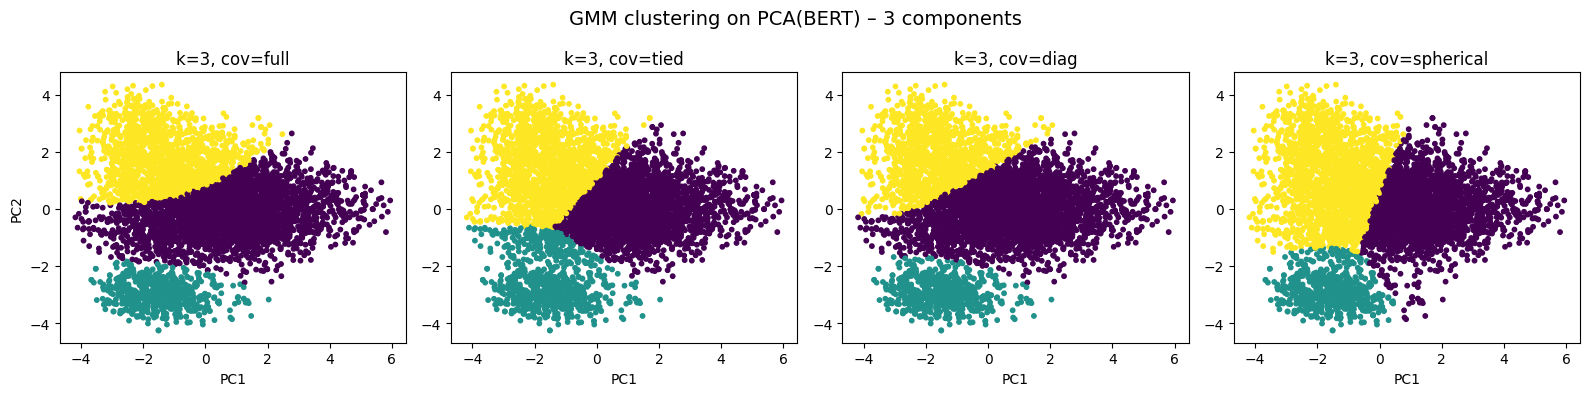

In [53]:
plt.figure(figsize=(16, 4))

for i, cov in enumerate(cov_types):
    gmm = GaussianMixture(n_components=3, covariance_type=cov, random_state=42)
    gmm.fit(X_pca)
    labels = gmm.predict(X_pca)

    ax = plt.subplot(1, 4, i + 1)
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, s=10, cmap="viridis")
    ax.set_title(f"k=3, cov={cov}")
    ax.set_xlabel("PC1")
    if i == 0:
        ax.set_ylabel("PC2")

plt.suptitle("GMM clustering on PCA(BERT) – 3 components", fontsize=14)
plt.tight_layout()
plt.show()

<font color="orange"> 

#### k = 3, covariance = full
- Spam forms a small distinct cluster (teal).
- Ham breaks into two meaningful subclusters (yellow vs purple).

Full covariance exposes hidden semantic subclasses inside ham. Excellent model fit, strong ARI/NMI metrics.

#### k = 3, covariance = tied
- Similar to full model but boundaries straighter.
- Clusters overlap more, particularly between two ham subregions.

Captures 3-way structure, but constraining covariance reduces expressivity, slightly less clear separation than full.

#### k = 3, covariance = diag
- Three clusters well separated, similar to full but more compact.
- The lower-left group (spam) remains most distinct.
- Good separation between two ham subclusters.

Among all models tested, k=3 diag achieved the best scores (ARI/NMI). Balance of flexibility + regularization is very effective here.

#### k = 3, covariance = spherical
- Clusters turned into circular blobs, several overlapping edges.
- Spam still visible but ham splits less cleanly.

Better than spherical k=2, but still inferior to full/diag. Oversimplification of variance reduces separation clarity.

<font color="orange"> 

#### Conclusion :
k=2 assumes only spam vs ham, binary world.\
k=3 reveals that ham actually contains multiple semantic styles, which BERT embeddings capture.\
So :
- If the goal is to simply separate spam from ham, then k = 2, full is sufficient.
- If the goal is to uncover internal linguistic structure, then k = 3, diag is best.

### Question 15
Comparez ces modèles en utilisant le test du rapport de vraisemblance. Quel est le modèle plausible le plus simple ?

<font color="green"> 

- gmm_simple  : GMM with fewer components (e.g. k=2) 
- gmm_complex : GMM with more components (e.g. k=3) 
- In a likelihood-ratio test comparing:

$H_0$ : k = 2 components \
$H_1$ : k = 3 components

for the same covariance type, the df (degree of freedom) is: \
$df=parameters(k=3)−parameters(k=2)$
- Means : $ k d $
- Weights : $k - 1$
And for:
1. Covariance = full : $k \frac{d(d+1)}{2}$

2. Covariance = tied : $\frac{d(d+1)}{2}$

3. Covariance = diag : $k d$

In [54]:
def likelihood_ratio_test(gmm_simple, gmm_complex, X):
    # total log-likelihoods
    LL_simple  = gmm_simple.score(X) * X.shape[0]
    LL_complex = gmm_complex.score(X) * X.shape[0]

    # LRT statistic
    LRT = 2 * (LL_complex - LL_simple)

    # parameter counting
    def count_params(gmm, d):
        K = gmm.n_components
        means = K * d
        weights = K - 1

        if gmm.covariance_type == "full":
            cov = K * d * (d + 1) / 2
        elif gmm.covariance_type == "tied":
            cov = d * (d + 1) / 2
        elif gmm.covariance_type == "diag":
            cov = K * d
        else:  # spherical
            cov = K
        return int(means + weights + cov)

    d = X.shape[1]
    df = count_params(gmm_complex, d) - count_params(gmm_simple, d)
    p_value = 1 - chi2.cdf(LRT, df)
    return LRT, p_value, df


In [55]:
gmm_models = {}

for k in components:
    for cov in cov_types:
        gmm = GaussianMixture(n_components=k,
                              covariance_type=cov).fit(X_pca)
        gmm_models[f"{k}_{cov}"] = gmm


In [56]:
rows = []

for cov in cov_types:
    gmm_2 = gmm_models[f"2_{cov}"]
    gmm_3 = gmm_models[f"3_{cov}"]

    LRT, p_val, df = likelihood_ratio_test(gmm_2, gmm_3, X_pca)

    rows.append([cov, LRT, df, p_val])

df_lrt = pd.DataFrame(
    rows,
    columns=["Covariance", "LR_stat", "df", "p_value"]
)

print(df_lrt)

  Covariance      LR_stat  df  p_value
0       full   880.710938   6      0.0
1       tied  1357.316406   3      0.0
2       diag   769.468750   5      0.0
3  spherical   985.828125   4      0.0


<font color="orange"> 

- All LR statistics are huge compared to chi2(df) thresholds.
- Since p_value is null, we can not accept $H_0$ and the model with k = 3 components explains the data significantly better than k = 2, for all covariance structures.
